In [1]:
from pythtb import TBModel, Lattice
import numpy as np

In [2]:
lat_vecs = [[1, 0], [1/2, np.sqrt(3) / 2]]
orb_vecs = [[1/3, 1/3], [2/3, 2/3]]
lat = Lattice(lat_vecs, orb_vecs, periodic_dirs=[0, 1])
model = TBModel(lattice=lat, spinful=False)

In [3]:
t1 = 1
delta = 1
t2 = 1
phi = np.pi / 2

model.set_onsite([-delta, delta], mode="set")

for lvec in ([0, 0], [-1, 0], [0, -1]):
    model.set_hop(t1, 0, 1, lvec, mode="set")

for lvec in ([1, 0], [-1, 1], [0, -1]):
    model.set_hop(t2 * np.exp(1j*phi), 0, 0, lvec, mode="set")
for lvec in ([-1, 0], [1, -1], [0, 1]):
    model.set_hop(t2 * np.exp(1j*phi), 1, 1, lvec, mode="set")

In [4]:
from pythtb.models import haldane
my_model = haldane(delta=0.1, t1=1.0, t2=0.1)

In [5]:
print(my_model)

----------------------------------------
       Tight-binding model report       
----------------------------------------
r-space dimension           = 2
k-space dimension           = 2
spinful                     = False
periodic directions         = [0, 1]
number of spin components   = 1
number of electronic states = 2
number of orbitals          = 2

Lattice vectors (Cartesian):
  # 0 ===> [ 1.000,  0.000]
  # 1 ===> [ 0.500,  0.866]
Volume of unit cell (Cartesian) = 0.866 [A^d]

Reciprocal lattice vectors (Cartesian):
  # 0 ===> [ 6.283, -3.628]
  # 1 ===> [ 0.000,  7.255]
Volume of reciprocal unit cell = 45.586 [A^-d]

Orbital vectors (Cartesian):
  # 0 ===> [ 0.500,  0.289]
  # 1 ===> [ 1.000,  0.577]
Orbital vectors (fractional):
  # 0 ===> [ 0.333,  0.333]
  # 1 ===> [ 0.667,  0.667]
----------------------------------------
Site energies:
  # 0 ===> -0.100 
  # 1 ===>  0.100 
Hoppings:
  < 0 | H | 1 + [ 0.0 ,  0.0 ] >  ===> 1.0000+0.0000j
  < 0 | H | 1 + [-1.0 ,  0.0 ] >  ===>

(<Figure size 800x800 with 1 Axes>, <Axes: xlabel='x', ylabel='y'>)

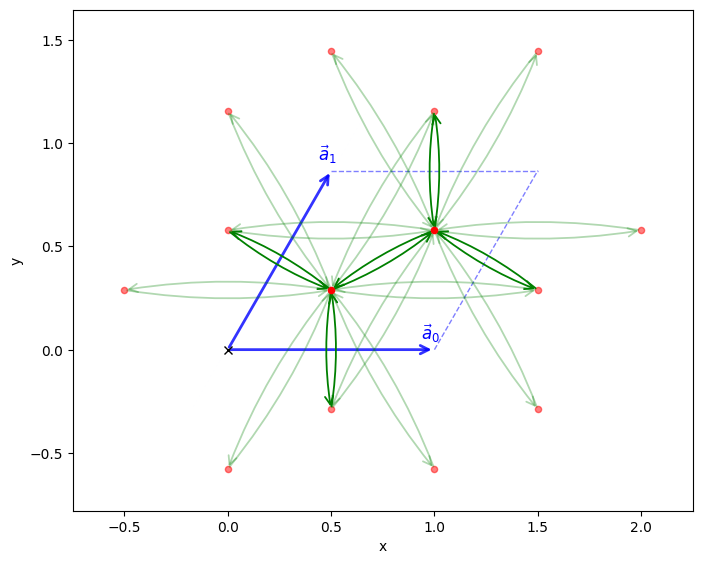

In [6]:
my_model.visualize(annotate_onsite_en=False)

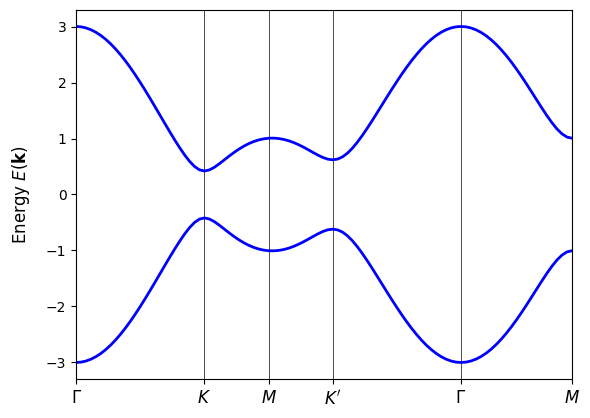

In [7]:
k_nodes = [[0, 0], [2/3, 1/3], [0.5, 0.5], [1/3, 2/3], [0, 0], [0.5, 0.5]]
k_label = (r'$\Gamma $',r'$K$', r'$M$', r'$K^\prime$', r'$\Gamma $', r'$M$')

fig, ax = my_model.plot_bands(k_nodes=k_nodes, k_node_labels=k_label)

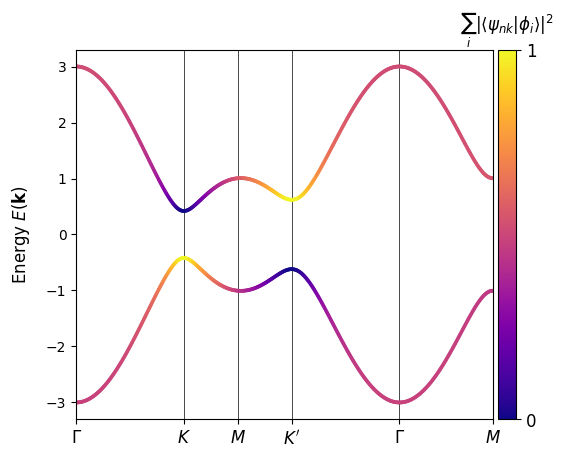

In [8]:
fig, ax = my_model.plot_bands(nk=500, k_nodes=k_nodes, k_node_labels=k_label, proj_orb_idx=[1]) 

In [9]:
# Generate k-points
nkx, nky = 20, 20
k_pts = my_model.k_uniform_mesh([nkx, nky])

In [10]:
b_curv_na = my_model.berry_curvature(k_pts=k_pts, occ_idxs=[0], cartesian=True, non_abelian=True)
print(b_curv_na.shape)

(2, 2, 400, 1, 1)


In [11]:
print(np.allclose(b_curv_na[0,1], -b_curv_na[1,0]))  # should be True
print(np.allclose(b_curv_na[0,0], 0))  # should be True
print(np.allclose(b_curv_na[1,1], 0))  # should be True

True
True
True


In [12]:
print("Chern number band 0:", my_model.chern_number([0], nk=200))
print("Chern number band 1:", my_model.chern_number([1], nk=200))

Chern number band 0: -1.0


Chern number band 1: 1.0


In [13]:
b_curv = my_model.berry_curvature(k_pts=k_pts, plane=(0, 1), occ_idxs=[0])
print(b_curv.shape)

(400,)


In [14]:
k_pts = k_pts.reshape((nkx, nky, 2))
b_curv = b_curv.reshape((nkx, nky))

Text(0.5, 1.0, 'Berry curvature from TBModel')

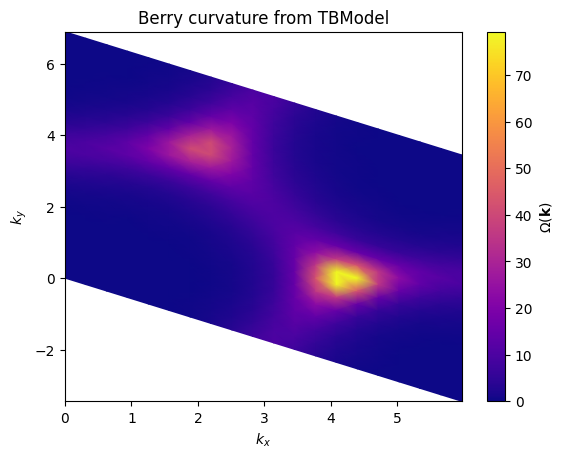

In [15]:
import matplotlib.pyplot as plt

recip_lat_vecs = my_model.recip_lat_vecs
mesh_Cart = k_pts @ recip_lat_vecs

KX = mesh_Cart[:, :, 0]
KY = mesh_Cart[:, :, 1]

im = plt.pcolormesh(KX, KY, abs(b_curv), cmap='plasma', shading='gouraud')
plt.xlabel(r'$k_x$')
plt.ylabel(r'$k_y$')
plt.colorbar(label=r'$\Omega(\mathbf{k})$')
plt.title('Berry curvature from TBModel')

In [16]:
from pythtb import tb_model
import numpy as np

In [17]:
# define lattice vectors
lat=[[1.0,0.0],[0.5,np.sqrt(3.0)/2.0]]
# define coordinates of orbitals
orb=[[1./3.,1./3.],[2./3.,2./3.]]

# make two dimensional tight-binding Haldane model
my_model=tb_model(2,2,lat,orb)

# set model parameters
delta=0.2
t=-1.0
t2 =0.15*np.exp((1.j)*np.pi/2.)
t2c=t2.conjugate()

# set on-site energies
my_model.set_onsite([-delta,delta])
# set hoppings (one for each connected pair of orbitals)
# (amplitude, i, j, [lattice vector to cell containing j])
my_model.set_hop(t, 0, 1, [ 0, 0])
my_model.set_hop(t, 1, 0, [ 1, 0])
my_model.set_hop(t, 1, 0, [ 0, 1])
# add second neighbour complex hoppings
my_model.set_hop(t2 , 0, 0, [ 1, 0])
my_model.set_hop(t2 , 1, 1, [ 1,-1])
my_model.set_hop(t2 , 1, 1, [ 0, 1])
my_model.set_hop(t2c, 1, 1, [ 1, 0])
my_model.set_hop(t2c, 0, 0, [ 1,-1])
my_model.set_hop(t2c, 0, 0, [ 0, 1])

# print tight-binding model
my_model.display()

----------------------------------------
       Tight-binding model report       
----------------------------------------
r-space dimension           = 2
k-space dimension           = 2
spinful                     = False
periodic directions         = [0, 1]
number of spin components   = 1
number of electronic states = 2
number of orbitals          = 2

Lattice vectors (Cartesian):
  # 0 ===> [ 1.000,  0.000]
  # 1 ===> [ 0.500,  0.866]
Volume of unit cell (Cartesian) = 0.866 [A^d]

Reciprocal lattice vectors (Cartesian):
  # 0 ===> [ 6.283, -3.628]
  # 1 ===> [ 0.000,  7.255]
Volume of reciprocal unit cell = 45.586 [A^-d]

Orbital vectors (Cartesian):
  # 0 ===> [ 0.500,  0.289]
  # 1 ===> [ 1.000,  0.577]
Orbital vectors (fractional):
  # 0 ===> [ 0.333,  0.333]
  # 1 ===> [ 0.667,  0.667]
----------------------------------------
Site energies:
  # 0 ===> -0.200 
  # 1 ===>  0.200 
Hoppings:
  < 0 | H | 1 + [ 0.0 ,  0.0 ] >  ===> -1.0000+0.0000j
  < 1 | H | 0 + [ 1.0 ,  0.0 ] >  ===

/var/folders/nn/m4t491h92ss8vwl56z761h6c0000gn/T/ipykernel_28984/772043602.py:7: DeprecationWarning: pythtb.tb_model is deprecated and will be removed in a future release. Use TBModel instead.
  my_model=tb_model(2,2,lat,orb)
/var/folders/nn/m4t491h92ss8vwl56z761h6c0000gn/T/ipykernel_28984/772043602.py:31: FutureWarning: TBModel.display is deprecated and will be removed in a future release: The 'display' method is deprecated and will be removed in a future release. Use 'print(model)' or 'model.info(show=True)' instead.
  my_model.display()
